In [8]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from data_loader import load_crashes, load_persons, load_vehicles

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Datasets

In [9]:
# 1. Load Datasets (SAFE SAMPLE VERSION)

# Option: how many rows to load from each dataset
SAMPLE_ROWS = 50000   # you can try 20_000 or 100_000 later if your laptop is okay

# Crashes dataset (sample)
crashes_url = "https://data.cityofnewyork.us/api/views/h9gi-nx95/rows.csv?accessType=DOWNLOAD"
df_crashes = pd.read_csv(
    crashes_url,
    low_memory=False,
    nrows=SAMPLE_ROWS      # <-- LIMIT rows to avoid memory explosion
)

# Persons dataset (sample)
persons_url = "https://data.cityofnewyork.us/api/views/f55k-p6yu/rows.csv?accessType=DOWNLOAD"
df_persons = pd.read_csv(
    persons_url,
    low_memory=False,
    nrows=SAMPLE_ROWS      # <-- LIMIT rows here too
)

print(f"Crashes dataset shape (sample): {df_crashes.shape}")
print(f"Persons dataset shape (sample): {df_persons.shape}")

df_crashes.head(), df_persons.head()


Crashes dataset shape (sample): (50000, 29)
Persons dataset shape (sample): (50000, 21)


(   CRASH DATE CRASH TIME   BOROUGH  ZIP CODE  LATITUDE  LONGITUDE  \
 0  09/11/2021       2:39       NaN       NaN       NaN        NaN   
 1  03/26/2022      11:45       NaN       NaN       NaN        NaN   
 2  11/01/2023       1:29  BROOKLYN   11230.0  40.62179 -73.970024   
 3  06/29/2022       6:55       NaN       NaN       NaN        NaN   
 4  09/21/2022      13:21       NaN       NaN       NaN        NaN   
 
                  LOCATION           ON STREET NAME CROSS STREET NAME  \
 0                     NaN    WHITESTONE EXPRESSWAY         20 AVENUE   
 1                     NaN  QUEENSBORO BRIDGE UPPER               NaN   
 2  (40.62179, -73.970024)            OCEAN PARKWAY          AVENUE K   
 3                     NaN       THROGS NECK BRIDGE               NaN   
 4                     NaN          BROOKLYN BRIDGE               NaN   
 
   OFF STREET NAME  NUMBER OF PERSONS INJURED  NUMBER OF PERSONS KILLED  \
 0             NaN                          2                  

## 2. Basic Dataset Information

In [10]:
# TODO: Display shape, columns, data types, memory usage
# Dataset info: columns, types, memory usage
df_crashes.info()
df_persons.info()

# Quick statistics for numeric columns
df_crashes.describe()
df_persons.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CRASH DATE                     50000 non-null  object 
 1   CRASH TIME                     50000 non-null  object 
 2   BOROUGH                        32714 non-null  object 
 3   ZIP CODE                       32708 non-null  float64
 4   LATITUDE                       46090 non-null  float64
 5   LONGITUDE                      46090 non-null  float64
 6   LOCATION                       46090 non-null  object 
 7   ON STREET NAME                 36419 non-null  object 
 8   CROSS STREET NAME              23085 non-null  object 
 9   OFF STREET NAME                13580 non-null  object 
 10  NUMBER OF PERSONS INJURED      50000 non-null  int64  
 11  NUMBER OF PERSONS KILLED       50000 non-null  int64  
 12  NUMBER OF PEDESTRIANS INJURED  50000 non-null 

,UNIQUE_ID,COLLISION_ID,VEHICLE_ID,PERSON_AGE
count,5.000000e+04,5.000000e+04,2.343500e+04,28751.000000
mean,8.185809e+06,3.853066e+06,1.915728e+07,42.223157
std,2.052164e+06,3.837237e+05,2.630609e+05,122.806559
min,1.257833e+06,2.607000e+03,8.397594e+06,-957.000000
25%,6.263877e+06,3.482562e+06,1.914486e+07,27.000000
50%,6.721359e+06,3.590380e+06,1.914795e+07,38.000000
75%,1.026244e+07,4.232218e+06,1.915118e+07,53.000000
max,1.335641e+07,4.810431e+06,2.086743e+07,9999.000000


## 3. Missing Values Analysis

Crashes missing values:
CRASH DATE                           0
CRASH TIME                           0
BOROUGH                          17286
ZIP CODE                         17292
LATITUDE                          3910
LONGITUDE                         3910
LOCATION                          3910
ON STREET NAME                   13581
CROSS STREET NAME                26915
OFF STREET NAME                  36420
NUMBER OF PERSONS INJURED            0
NUMBER OF PERSONS KILLED             0
NUMBER OF PEDESTRIANS INJURED        0
NUMBER OF PEDESTRIANS KILLED         0
NUMBER OF CYCLIST INJURED            0
NUMBER OF CYCLIST KILLED             0
NUMBER OF MOTORIST INJURED           0
NUMBER OF MOTORIST KILLED            0
CONTRIBUTING FACTOR VEHICLE 1      250
CONTRIBUTING FACTOR VEHICLE 2    11185
CONTRIBUTING FACTOR VEHICLE 3    44669
CONTRIBUTING FACTOR VEHICLE 4    48550
CONTRIBUTING FACTOR VEHICLE 5    49577
COLLISION_ID                         0
VEHICLE TYPE CODE 1                601
V

<Axes: >

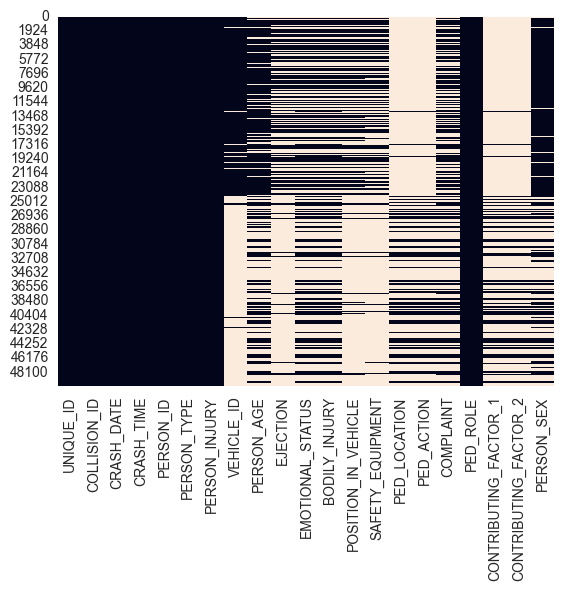

In [11]:
# TODO: Analyze missing values per column
# Visualize missing data patterns
# Missing values count per column
print("Crashes missing values:")
print(df_crashes.isnull().sum())

print("\nPersons missing values:")
print(df_persons.isnull().sum())
sns.heatmap(df_crashes.isnull(), cbar=False)
sns.heatmap(df_persons.isnull(), cbar=False)



## 4. Data Quality Checks

In [12]:
# TODO: Check for duplicates
# Identify outliers
# Validate data types
# Check duplicates
print("Crashes duplicates:", df_crashes.duplicated().sum())
print("Persons duplicates:", df_persons.duplicated().sum())


Crashes duplicates: 0
Persons duplicates: 0


## 5. Exploratory Visualizations

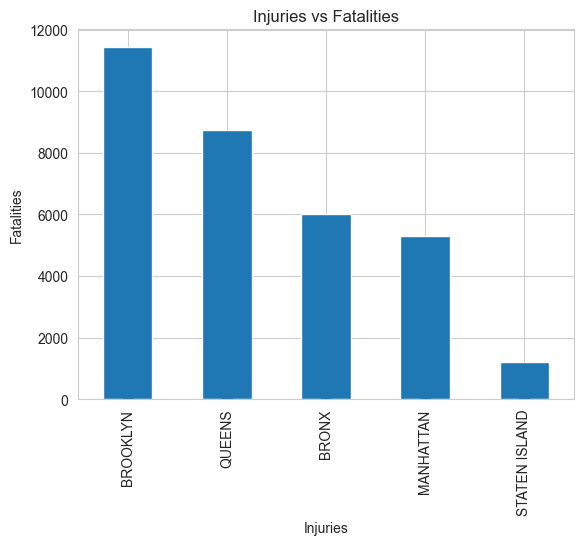

In [13]:
# TODO: Create initial visualizations
# Distribution plots
# Time series analysis
# Correlation analysis
# Number of crashes per borough
df_crashes['BOROUGH'].value_counts().plot(kind='bar', title='Crashes per Borough')

# Injuries vs fatalities
plt.scatter(df_crashes['NUMBER OF PERSONS INJURED'], df_crashes['NUMBER OF PERSONS KILLED'])
plt.xlabel("Injuries")
plt.ylabel("Fatalities")
plt.title("Injuries vs Fatalities")
plt.show()


## 6. Key Findings and Next Steps

**TODO: Document findings:**
- Data quality issues identified
- Missing value patterns
- Columns to keep/drop
- Cleaning strategies for next notebook

In [14]:
# Save raw versions for later cleaning notebooks (optional but smart)

from pathlib import Path

processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Save full data (or you can sample to make later notebooks faster)
df_crashes.to_parquet(processed_dir / "crashes_raw.parquet", index=False)
df_persons.to_parquet(processed_dir / "persons_raw.parquet", index=False)

print("Saved:", processed_dir.glob("*.parquet"))


Saved: <generator object Path.glob at 0x1171a7a50>
